Esta primeira atividade faremos um detector da frequencia fundamental (Pitch) para notas de guitarra.

Vamos utilizar o dataset https://www.kaggle.com/juliancienfuegos/what-is-a-note

Será útil para aprender a carregar e manipular arquivos de áudio, e também extraír algumas features.

Matrial de consulta: https://musicinformationretrieval.com/index.html

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shutil
import os
import re

In [ ]:
# if os.path.exists('GuitarNotes'):
#     shutil.rmtree('GuitarNotes')
#     print("Folder 'GuitarNotes' removed.")

# !wget https://github.com/juancolonna/UEA-2025-ML-course/raw/main/datasets/GuitarNotes.zip
# !unzip -q GuitarNotes.zip

# dir = # "GuitarNotes"


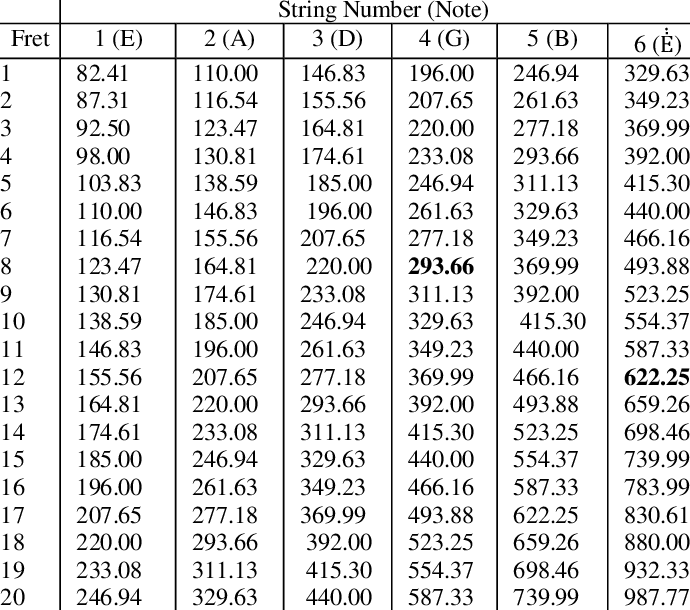

In [ ]:
# notes_freqs= {'Elo0':82.41,'Elo1':87.31,'Elo2':92.50,'Elo3':98.00,'Elo4':103.83,'Elo5':110,'Elo6':116.54,'Elo7':123.47,'Elo8':130.81,
#               'A0':110,'A1':116.54,'A2':123.47,'A3':130.81,'A4':138.59,'A5':146.83,'A6':155.56,'A7':164.81,'A8':174.61,
#               'D0':146.83,'D1':155.56,'D2':164.81,'D3':174.61,'D4':185,'D5':196,'D6':207.65,'D7':220,'D8':233.08,
#               'G0':196,'G1':207.65,'G2':220,'G3':233.08,'G4':246.94,'G5':261.63,'G6':277.18,'G7':293.66,'G8':311.13,
#               'B0':246.94,'B1':261.63,'B2':277.18,'B3':293.66,'B4':311.13,'B5':329.63,'B6':349.23,'B7':369.99,'B8':392,
#               'Ehi0':329.63,'Ehi1':349.23,'Ehi2':369.99,'Ehi3':392,'Ehi4':415.30,'Ehi5':440,'Ehi6':466.16,'Ehi7':493.88,'Ehi8':523.25}

# minFr = 80
# maxFr = 530

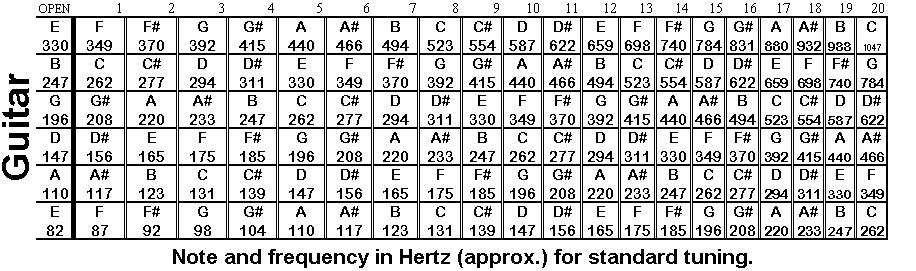

In [ ]:
# notes_codes= {'Elo0':'Elo','Elo1':'F','Elo2':'F#','Elo3':'G','Elo4':'G#','Elo5':'A','Elo6':'A#','Elo7':'B','Elo8':'C',
#               'A0':'A','A1':'A#','A2':'B','A3':'C','A4':'C#','A5':'D','A6':'D#','A7':'E','A8':'F',
#               'D0':'D','D1':'D#','D2':'E','D3':'F','D4':'F#','D5':'G','D6':'G#','D7':'A','D8':'A#',
#               'G0':'G','G1':'G#','G2':'A','G3':'A#','G4':'B','G5':'C','G6':'C#','G7':'D','G8':'D#',
#               'B0':'B','B1':'C','B2':'C#','B3':'D','B4':'D#','B5':'E','B6':'F','B7':'F#','B8':'G',
#               'Ehi0':'Ehi','Ehi1':'F','Ehi2':'F#','Ehi3':'G','Ehi4':'G#','Ehi5':'A','Ehi6':'A#','Ehi7':'B','Ehi8':'C'}

In [ ]:
# # Load the list of wav files
# files = [f for f in os.listdir(dir) if f.endswith('.wav')]
# files.sort()

# # # We also define a dataframe containing the filenames, we will use this later
# df_files = pd.DataFrame(files)
# df_files.columns = ['File']

# df_test = df_files[0:8]
# df_train = df_files.loc[8:]
# df_train = df_train.reset_index(drop=True)

# df_train['Label'] = ""
# df_train['String'] = ""
# df_train['Freq'] = ""

# for index, row in df_train.iterrows():
#     chord_freq = row['File'].split('.')
#     df_train['Label'][index] = chord_freq[0]
#     df_train['String'][index] = str(chord_freq[0].rstrip('0123456789'))
#     df_train['Freq'][index] = notes_freqs[chord_freq[0]]

# df_train['Freq'] = df_train['Freq'].astype(float)
# df_train

In [ ]:
# df_files

## Carregando um arquivo de áudio em um vetor

In [ ]:
# import librosa
# import librosa.display

# nota = 2 # testar 0 e 2

# x, sr = librosa.load(dir + '/' + df_train['File'][nota])
# print(sr)
# print(len(x)/sr)


# # normalizando e removendo o offset
# x = (x - np.mean(x))/np.std(x)

# n = len(x)
# n

## Visualizando a série de tempo

In [ ]:
# plt.figure(figsize=(15,4))
# plt.plot(x ,'-')
# plt.title(df_train['Label'][nota]);
# plt.xlabel('time (s)')
# # plt.xlim([5080, 5100]);
# # plt.ylim([-5,5])
# plt.grid()

## Visulizando um áudio e seu espectro de frequências

A FFT de um sinal discreto é:

$f_k = \sum_{n=0}^{N-1} x_n ~ e^{-2\pi j \frac{kn}{N}}$

a inversa do espectro de frequencias é:

$x_n = \frac{1}{N} \sum_{k=0}^{N-1} f_k ~ e^{2\pi j \frac{kn}{N}}$

In [ ]:
# # Espectro de freqências
# spectrum = np.abs(librosa.stft(...,  n_fft = n, center=False)) # x
# freqs = librosa.fft_frequencies(sr = sr, n_fft = n)

In [ ]:
# plt.figure(figsize=(25,4))
# plt.subplot(1,2,1)
# plt.plot(x)
# plt.title(df_train['Label'][nota]);
# plt.xlabel('time (s)')
# # plt.xlim([0, 1000]);
# plt.grid()

# plt.subplot(1,2,2)
# plt.plot(freqs, spectrum)
# plt.xlabel('Freqs (Hz)')
# plt.title(df_train['Label'][nota]);
# plt.vlines(df_train['Freq'][nota], -400, np.max(spectrum)+400, colors='red',linestyles='-.')
# plt.xlim([0, 1e3]);

## Playing um áudio

In [ ]:
# import IPython.display as ipd

# ipd.Audio(dir + '/' + df_train['File'][nota])

## Extraíndo algumas features dos áudios

Spectral centroid:

$f_c = \frac{\sum_k S(k)f(k)}{\sum_k S(k)}$

where $S(k)$ is the spectral magnitude at frequency bin $k$ and $f(k)$ is the frequency at bin $k$.

----

Spectral bandwidth:

B = $\Big(\sum_k S(k) \big( f(k) - f_c \big)^2 \Big)^{(1/2)}$

----

Autocorrelação:

$R_{xx} = \frac{1}{r} \sum_{n=1}^{N-r} x_n x_{n+r}; ~~~ r=\{0,1,2, \dots, (N-r)/2\}$

----

Pitch:

$\text{Pitch} = \underset{r}{\text{max}} ~ R_{xx}$

## Variação do spectral centroid

In [ ]:
# spectral_centroids = librosa.feature.spectral_centroid(y=x, sr=sr, n_fft=1024)[0]

# frames = range(len(spectral_centroids))
# t = librosa.frames_to_time(frames)

# plt.figure(figsize=(15,5))
# librosa.display.waveshow(x, sr=sr, alpha=0.4)
# plt.plot(t, 0.005*spectral_centroids, color='r'); # normalize for visualization purposes

## Variação do Pitch

In [ ]:
# pitches = librosa.yin(x, fmin=minFr, fmax=maxFr, sr=sr, frame_length=512 )

# frames = range(len(pitches))
# t = librosa.frames_to_time(frames, hop_length=512//4)

# plt.figure(figsize=(15,5))
# librosa.display.waveshow(x, sr=sr, alpha=0.4)
# plt.plot(t, 0.01*pitches, color='r'); # normalize for visualization purposes

Spectrograma


In [ ]:
# X_stft = librosa.stft(x)
# X_db = librosa.amplitude_to_db(abs(X_stft))

# plt.figure(figsize=(15, 5))
# librosa.display.specshow(X_db, sr=sr, x_axis='time', y_axis='log')
# plt.colorbar()
# plt.title(f'Spectrogram of {df_train["Label"][nota]}')
# plt.show()

## Extração de features para todas as notas

In [ ]:
# def extract_features(x, fs, filter=False):
#     n = len(x)
#     if filter:
#         filter_len = 10
#         x = np.convolve(x, np.ones(filter_len)/filter_len, mode='same')

#     spectrum = np.abs(librosa.stft(x, n_fft = n, center = False))
#     freqs = librosa.fft_frequencies(sr = sr, n_fft = n)

#     zero_crossings = sum(librosa.zero_crossings(x, pad=False))
#     zc_pitch = (zero_crossings*fs)/(2*n)

#     cent = librosa.feature.spectral_centroid(y=x, sr=fs, S=spectrum)[0][0]
#     bandwidth = librosa.feature.spectral_bandwidth(y=x, sr=fs, S=spectrum)[0][0]
#     max_freq = freqs[np.argmax(spectrum)]
#     pitch = librosa.yin(x, fmin=minFr, fmax=maxFr, sr=fs, frame_length=n, center=False)[0]

#     return zc_pitch, cent, bandwidth, max_freq, pitch

In [ ]:
# from tqdm.notebook import tqdm

# for newcol in ['N','sr','zc_pitch','cent','bandwidth','max_freq','pitch']:
#     df_train[newcol] = 0.0

# X_train = []

# for index, row in tqdm(df_train.iterrows()):
#     y, sr = librosa.load(dir + '/' + row['File'])
#     y = (y - np.mean(y))/np.std(y)
#     n = len(y)

#     zc_pitch, cent, bandwidth, max_freq, pitch = extract_features(y, sr, filter=True)

#     df_train.loc[index, ['N']] = n
#     df_train.loc[index, ['sr']] = sr
#     df_train.loc[index,['zc_pitch']] = zc_pitch
#     df_train.loc[index,['cent']] = cent
#     df_train.loc[index,['bandwidth']] = bandwidth
#     df_train.loc[index,['max_freq']] = max_freq
#     df_train.loc[index,['pitch']] = pitch

In [ ]:
df_train.head()

### Diferencas usando o Pitch e informando a corda e o traste apertado

In [ ]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.preprocessing import MinMaxScaler

# enc = OneHotEncoder()
# one_hot_strings = enc.fit_transform(df_train['String'].values.reshape(-1,1)).toarray()

# norm = MinMaxScaler()
# norm_freqs = norm.fit_transform(df_train['Freq'].values.reshape(-1,1))

# # X_train = norm_freqs
# X_train = np.concatenate((one_hot_strings,norm_freqs),axis=1)

# knn = KNeighborsClassifier(n_neighbors=2)
# neighbors = knn.fit(X_train, df_train['Label'].values)

In [ ]:
# X_train[0:2]

In [ ]:
# pitch = norm.transform(df_train['pitch'].values.reshape(-1,1))
# # X_test = pitch
# X_test = np.concatenate((one_hot_strings, pitch),axis=1)
# y_pred = knn.predict(X_test)
# y_pred

In [ ]:
# from sklearn.metrics import classification_report
# from sklearn.metrics import ConfusionMatrixDisplay

# print(classification_report(df_train['Label'].values, y_pred))

# fig, ax = plt.subplots(figsize=(22, 17))
# ConfusionMatrixDisplay.from_estimator(knn, X_test, df_train['Label'].values, ax=ax)
# plt.show()

### Diferença entre os pitchs

In [ ]:
# freq_pitch_diff = df_train['Freq'].values - df_train['pitch'].values

# mask1 = freq_pitch_diff > 0.0
# mask2 = freq_pitch_diff <= 0.0

# y_pos = np.arange(len(df_train))

# fig, ax = plt.subplots(figsize=(25,5))
# ax.bar(y_pos[mask1], freq_pitch_diff[mask1], align='center', color='#6480e5')
# ax.bar(y_pos[mask2], freq_pitch_diff[mask2], align='center', color='#e56464')

# plt.xlim([-0.5,53.5])
# ax.set_xticks(y_pos)
# ax.set_xticklabels(df_train['Label'])
# ax.set_ylabel('Freq distance')
# plt.grid()
# plt.show()

### Diferenças usando a frequencia com maior energia

In [ ]:
# freq_pitch_diff = df_train['Freq'].values - df_train['max_freq'].values

# mask1 = freq_pitch_diff > 0.0
# mask2 = freq_pitch_diff <= 0.0

# y_pos = np.arange(len(df_train))

# fig, ax = plt.subplots(figsize=(25,5))
# ax.bar(y_pos[mask1], freq_pitch_diff[mask1], align='center', color='#6480e5')
# ax.bar(y_pos[mask2], freq_pitch_diff[mask2], align='center', color='#e56464')

# plt.xlim([-0.5,53.5])
# ax.set_xticks(y_pos)
# ax.set_xticklabels(df_train['Label'])
# ax.set_ylabel('Freq distance')
# plt.grid()
# plt.show()

Estimando a frequencia principal a partir do Zero-Crossing Rate

https://medium.com/the-seekers-project/algorithmic-frequency-pitch-detection-series-part-1-making-a-simple-pitch-tracker-using-zero-9991327897a4

In [ ]:
# freq_pitch_diff = df_train['Freq'].values - df_train['zc_pitch'].values

# mask1 = freq_pitch_diff > 0.0
# mask2 = freq_pitch_diff <= 0.0

# y_pos = np.arange(len(df_train))

# fig, ax = plt.subplots(figsize=(25,5))
# ax.bar(y_pos[mask1], freq_pitch_diff[mask1], align='center', color='#6480e5')
# ax.bar(y_pos[mask2], freq_pitch_diff[mask2], align='center', color='#e56464')

# plt.xlim([-0.5,53.5])
# ax.set_xticks(y_pos)
# ax.set_xticklabels(df_train['Label'])
# ax.set_ylabel('Freq distance')
# plt.grid()
# plt.show()

### Agrupamentos das notas

In [ ]:
# from sklearn.cluster import KMeans

# k = 6
# kmeans = KMeans(n_clusters=k)

# X = df_train[['pitch']].values
# X = df_train[['bandwidth']].values
# # X = df_train[['zc_pitch', 'cent', 'bandwidth', 'max_freq', 'pitch']].values
# kmeans.fit(X)

# y_kmeans = kmeans.predict(X)
# y_kmeans

In [ ]:
# for c in range(k):
#     l = df_train['Label'][y_kmeans == c].values
#     notas = list(notes_codes[_] for _ in l)
#     freqs = list(notes_freqs[_] for _ in l)
#     print('\n Cluster ' + str(c) + ':', notas,
#           '\n Frequencias: ', freqs)

In [ ]:
# import time

# cluster = 5

# for arq in df_train['File'][y_kmeans == cluster].values:
#     ipd.display(ipd.Audio(dir + '/' + arq))

In [ ]:
# import seaborn as sns

# df_plot = df_train[['Freq','zc_pitch', 'cent', 'bandwidth', 'max_freq', 'pitch', 'String']]
# sns.pairplot(df_plot, hue='String');

## Atividade

Verificar com as metricas silhouette e ELbow o melhor agrupamento.

Depois de gerar o novo agrupamento com o melhor k, classificar as amostras que faltaram ``df_test``